[INFO] Loaded CSV: /Users/jeonghyeontae/Motility_data_0210/all_segments_mobility_umap_sampled_svm_CombinedLabel_updated.csv
[INFO] total rows in df_all: 13786
[INFO] columns head: ['label', 'Color', 'speed', 'euclidean_dist', 'segment_length', 'cumulative_length', 'meandering_index', 'outreach_ratio', 'MSD', 'max_dist', 'arrest_coefficient', 'turn_count', 'neighbor_similarity', 'loop_score', 'angle_variation', 'curvature_count', 'polygon_area', 'turning_index', 'avg_acceleration', 'source_file']


100%|████████████████████████████████████| 13786/13786 [01:39<00:00, 138.91it/s]


✅ collected mask count: 13786
✅ Final: mask_array shape = (13786, 64, 64), df_valid shape = (13786, 110)
📦 캐시에 올라간 mask 파일 개수: 135
Epoch 1/200 - Loss: 13.7549
Epoch 2/200 - Loss: 2.0862
Epoch 3/200 - Loss: 1.3661
Epoch 4/200 - Loss: 1.1057
Epoch 5/200 - Loss: 0.9824
Epoch 6/200 - Loss: 0.8906
Epoch 7/200 - Loss: 0.8274
Epoch 8/200 - Loss: 0.7850
Epoch 9/200 - Loss: 0.7604
Epoch 10/200 - Loss: 0.7395
Epoch 11/200 - Loss: 0.7241
Epoch 12/200 - Loss: 0.7108
Epoch 13/200 - Loss: 0.7023
Epoch 14/200 - Loss: 0.6953
Epoch 15/200 - Loss: 0.6908
Epoch 16/200 - Loss: 0.6791
Epoch 17/200 - Loss: 0.6786
Epoch 18/200 - Loss: 0.6683
Epoch 19/200 - Loss: 0.6669
Epoch 20/200 - Loss: 0.6671
Epoch 21/200 - Loss: 0.6604
Epoch 22/200 - Loss: 0.6545
Epoch 23/200 - Loss: 0.6526
Epoch 24/200 - Loss: 0.6468
Epoch 25/200 - Loss: 0.6447
Epoch 26/200 - Loss: 0.6404
Epoch 27/200 - Loss: 0.6363
Epoch 28/200 - Loss: 0.6357
Epoch 29/200 - Loss: 0.6329
Epoch 30/200 - Loss: 0.6272
Epoch 31/200 - Loss: 0.6248
Epoch 32/

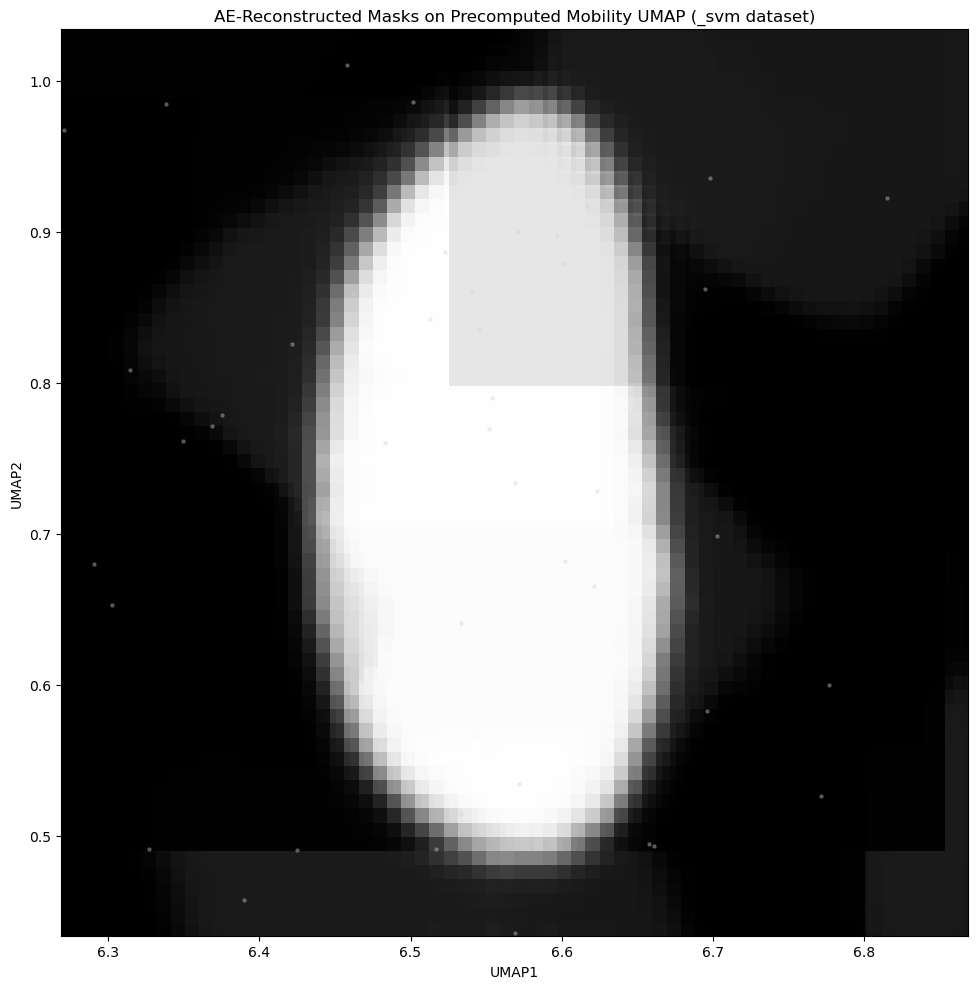

✅ Saved AE weights -> ae_svm_state.pt
✅ Saved latent UMAP profile -> latent_umap_profile_svm.joblib


In [14]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from skimage.measure import regionprops
from skimage.transform import resize, rotate

import matplotlib.pyplot as plt
import joblib

# ============================================
# User Setting for encoding
# ============================================
CSV_PATH   = "/Users/jeonghyeontae/Motility_data_0210/all_segments_mobility_umap_sampled_svm_CombinedLabel_updated.csv"  # 경로 맞게 수정
MAX_MASKS  = 20000
MASK_SIZE  = (64, 64)
LATENT_DIM = 16
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GRID_SIZE        = 15
MIN_COUNT_GRID   = 10

np.random.seed(0)
torch.manual_seed(0)

# ============================================
# CSV file loading, from the whole-data saved csv file
# ============================================
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df_all = pd.read_csv(CSV_PATH)
print("[INFO] Loaded CSV:", CSV_PATH)
print("[INFO] total rows in df_all:", len(df_all))
print("[INFO] columns head:", df_all.columns.tolist()[:20])

# Check the UMAP
if not {"UMAP1", "UMAP2"}.issubset(df_all.columns):
    raise RuntimeError("No CSV file with UMAP coordinate please check the file folder")

# ============================================
# 2. Cellpose Masks for each data raws_ It required whole data set for the cellpose segmented dataset
# ============================================
mask_cache = {}  # {mask_path: full_mask_array}


def load_cellpose_mask_with_cache(mask_path):
    mask_path = os.path.expanduser(str(mask_path).strip())
    if mask_path in mask_cache:
        return mask_cache[mask_path]

    if not os.path.exists(mask_path):
        return None

    arr = np.load(mask_path, allow_pickle=True)
    # case A: dict 형태 { 'masks': ... }
    if hasattr(arr, "item"):
        try:
            d = arr.item()
            if "masks" in d:
                full = d["masks"]
            else:
                full = arr
        except Exception:
            full = arr
    else:
        full = arr

    mask_cache[mask_path] = full
    return full


# ============================================
# _svm row -> single-cell mask
# ============================================
def get_mask_from_svm_row_cached(row, size=MASK_SIZE, pad=5):
    """
    from a row of df_all
    - matched_mask_file + matched_cell_label(or shape_Cell Label)
    - Cellpose full mask locations --> get the boundary information
    - bbox+orientation 
    """
    if "matched_mask_file" not in row:
        return None

    raw_path = row["matched_mask_file"]
    if pd.isna(raw_path):
        return None

    full_mask = load_cellpose_mask_with_cache(raw_path)
    if full_mask is None:
        return None

    # label of cells : matched_cell_label first, if not shape_Cell Label
    cell_label = None
    if "matched_cell_label" in row and not pd.isna(row["matched_cell_label"]):
        cell_label = int(row["matched_cell_label"])
    elif "shape_Cell Label" in row and not pd.isna(row["shape_Cell Label"]):
        cell_label = int(row["shape_Cell Label"])
    else:
        return None

    # Cellpose Mask loading
    mask = full_mask
    if mask.ndim == 3:
        # (channel, H, W) : Use first channel
        mask = mask[0]

    cell_mask = (mask == cell_label).astype(np.uint8)
    if cell_mask.sum() == 0:
        return None

    # Get bbox, Orientation from regionprops
    props_list = regionprops(cell_mask)
    if len(props_list) == 0:
        return None
    props = props_list[0]

    minr, minc, maxr, maxc = props.bbox
    h, w = cell_mask.shape

    minr = max(minr - pad, 0)
    minc = max(minc - pad, 0)
    maxr = min(maxr + pad, h)
    maxc = min(maxc + pad, w)

    cropped = cell_mask[minr:maxr, minc:maxc].astype(float)

    # orientation rotation
    angle_deg = props.orientation * 180 / np.pi
    rotated = rotate(cropped, angle=-angle_deg, center=None, preserve_range=True)

    resized = resize(rotated, size, anti_aliasing=False).astype(np.float32)
    return resized


# ============================================
# Mask gathering
# ============================================
max_masks = MAX_MASKS
mask_list = []
valid_indices = []

print("Collecting masks from _svm... (shuffled + cached)")
sample_df = df_all.sample(frac=1, random_state=0)  # Shuffle data

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    m = get_mask_from_svm_row_cached(row)
    if m is not None:
        mask_list.append(m)
        valid_indices.append(idx)  # sample_df
        if len(mask_list) >= max_masks:
            break

print("collected mask count:", len(mask_list))

if len(mask_list) == 0:
    if "matched_mask_file" in df_all.columns:
        file_col = df_all["matched_mask_file"].astype(str).str.strip()
        exists_flags = file_col.apply(os.path.exists)
        print("Exist File count:", exists_flags.sum(), "/", len(exists_flags))
        print(file_col[exists_flags].head())
    raise RuntimeError("No mask please check the column name.")

mask_array = np.stack(mask_list)
df_valid = df_all.loc[valid_indices].reset_index(drop=True)

print(f"Final: mask_array shape = {mask_array.shape}, df_valid shape = {df_valid.shape}")
print(f"Total Mask number: {len(mask_cache)}")

# ============================================
# Autoencoder Dataset & Model
# ============================================
class MaskDataset(Dataset):
    def __init__(self, mask_array):
        # (N, H, W) -> (N, 1, H, W)
        self.data = torch.tensor(mask_array).unsqueeze(1).float()
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]


class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, 2, 1), nn.ReLU(),      # (1,64,64)->(8,32,32)
            nn.Conv2d(8, 16, 3, 2, 1), nn.ReLU(),     # (16,16,16)
            nn.Flatten(),
            nn.Linear(16 * 16 * 16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16 * 16 * 16),
            nn.Unflatten(1, (16, 16, 16)),
            nn.ConvTranspose2d(16, 8, 3, 2, 1, output_padding=1), nn.ReLU(),  # (8,32,32)
            nn.ConvTranspose2d(8, 1, 3, 2, 1, output_padding=1), nn.Sigmoid() # (1,64,64)
        )
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


dataset   = MaskDataset(mask_array)
loader    = DataLoader(dataset, batch_size=64, shuffle=True)
model     = ConvAutoencoder(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 200
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        recon, _ = model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss:.4f}")

# ============================================
# latent extraction
# ============================================
model.eval()
with torch.no_grad():
    z_all = model.encoder(
        torch.tensor(mask_array).unsqueeze(1).float().to(DEVICE)
    ).cpu().numpy()

print(f"[INFO] z_all shape: {z_all.shape}")

# ============================================
# AE overray on the pre-formed UMAP space
# ============================================
if not {"UMAP1", "UMAP2"}.issubset(df_valid.columns):
    raise RuntimeError("NO UMAP coordinates in df_valid Check column name.")

umap_xy  = df_valid[["UMAP1", "UMAP2"]].values
x_coords = umap_xy[:, 0]
y_coords = umap_xy[:, 1]

fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(x_coords, y_coords, s=5, c="lightgray", alpha=0.3)

for i in range(len(mask_array)):
    gx, gy = x_coords[i], y_coords[i]
    z = torch.tensor(z_all[i:i+1], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        recon = model.decoder(z).cpu().numpy()[0, 0]

    extent = [gx - 0.3, gx + 0.3, gy - 0.3, gy + 0.3]
    ax.imshow(recon, cmap="gray", extent=extent, alpha=0.9)

ax.set_title("AE-Reconstructed Masks on Precomputed Mobility UMAP (_svm dataset)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

def _make_grid_spec(umap_xy, grid_size=12):
    x_min, x_max = float(umap_xy[:, 0].min()), float(umap_xy[:, 0].max())
    y_min, y_max = float(umap_xy[:, 1].min()), float(umap_xy[:, 1].max())
    x_edges = np.linspace(x_min, x_max, grid_size + 1)
    y_edges = np.linspace(y_min, y_max, grid_size + 1)
    return dict(grid_size=grid_size, x_edges=x_edges, y_edges=y_edges,
                x_range=(x_min, x_max), y_range=(y_min, y_max))

def _assign_cells(umap_xy, x_edges, y_edges):
    ix = np.clip(np.digitize(umap_xy[:, 0], x_edges) - 1, 0, len(x_edges) - 2)
    iy = np.clip(np.digitize(umap_xy[:, 1], y_edges) - 1, 0, len(y_edges) - 2)
    return ix, iy

def build_latent_umap_profile(umap_xy_ref, z_ref, grid_size=12, min_count=10, eps=1e-8):
    latent_dim = z_ref.shape[1]
    grid = _make_grid_spec(umap_xy_ref, grid_size)
    ix, iy = _assign_cells(umap_xy_ref, grid["x_edges"], grid["y_edges"])

    g_mean = z_ref.mean(axis=0)
    g_var  = z_ref.var(axis=0) + eps

    cells = {}
    for i in range(grid_size):
        for j in range(grid_size):
            mask = (ix == i) & (iy == j)
            n = int(mask.sum())
            if n >= min_count:
                z_sub = z_ref[mask]
                cells[(i, j)] = {
                    "n": n,
                    "mean": z_sub.mean(axis=0),
                    "var":  z_sub.var(axis=0) + eps
                }

    return {
        "latent_dim": latent_dim,
        "grid": grid,
        "min_count": min_count,
        "eps": eps,
        "global": {"n": int(len(z_ref)), "mean": g_mean, "var": g_var},
        "cells": cells
    }

# Color one-hot
color_vocab = ["Black", "Green", "Red", "Yellow"]
if "Color_updated" in df_valid.columns:
    df_valid["Color_updated"] = df_valid["Color_updated"].astype(str).str.strip().str.title()
else:
    df_valid["Color_updated"] = "Unknown"

ohe_cols   = [f"Color_{c}" for c in color_vocab]
color_ohe  = np.zeros((len(df_valid), len(color_vocab)), dtype=float)
cmap_color = {c: i for i, c in enumerate(color_vocab)}
for r, cval in enumerate(df_valid["Color_updated"]):
    if cval in cmap_color:
        color_ohe[r, cmap_color[cval]] = 1.0

# latent + color one-hot
z_ref_aug = np.concatenate([z_all, color_ohe], axis=1)

profile = build_latent_umap_profile(
    umap_xy,
    z_ref_aug,
    grid_size=GRID_SIZE,
    min_count=MIN_COUNT_GRID
)
profile["color_vocab"]    = color_vocab
profile["latent_aug_dim"] = z_ref_aug.shape[1]

# Color histogram per grid of UMAP space
ix_ref, iy_ref = _assign_cells(umap_xy, profile["grid"]["x_edges"], profile["grid"]["y_edges"])
cell_color_hist = {}
for i in range(profile["grid"]["grid_size"]):
    for j in range(profile["grid"]["grid_size"]):
        m = (ix_ref == i) & (iy_ref == j)
        if m.sum() == 0:
            continue
        counts = Counter(df_valid.loc[m, "Color_updated"])
        cell_color_hist[(i, j)] = dict(counts)
profile["color_hist"] = cell_color_hist

# ============================================
# AE state + profile
# ============================================
torch.save(
    {
        "state_dict": model.state_dict(),
        "latent_dim": LATENT_DIM,
        "input_size": (1, MASK_SIZE[0], MASK_SIZE[1])
    },
    "ae_svm_state.pt"
)
joblib.dump(profile, "latent_umap_profile_svm.joblib")

print("Saved AE weights -> ae_svm_state.pt")
print("Saved latent UMAP profile -> latent_umap_profile_svm.joblib")


In [16]:
import os
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from skimage.segmentation import find_boundaries


SEG_COL = "Segment"
OUT_DIR = "umap_segment_panels"

GRID_SIZE = 15
MIN_GRID_POINTS = 8
MIN_KDE_POINTS = 20
MIN_COUNT = 20
MIN_SEGMENT_SIZE = 200

os.makedirs(OUT_DIR, exist_ok=True)


def subset_by_mask(df, mask_array, z_all, mask_bool):
    df_subset = df.loc[mask_bool].copy()
    mask_subset = mask_array[mask_bool]
    z_subset = z_all[mask_bool]
    return df_subset, mask_subset, z_subset


def normalize_01(values):
    values = values.astype(float).copy()
    if np.all(np.isnan(values)):
        return values

    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    return (values - vmin) / (vmax - vmin + 1e-8)


def compute_grid_indices(x_coords, y_coords, x_min, x_max, y_min, y_max, grid_size):
    dx = (x_max - x_min) / grid_size
    dy = (y_max - y_min) / grid_size

    ix = np.clip(((x_coords - x_min) / dx).astype(int), 0, grid_size - 1)
    iy = np.clip(((y_coords - y_min) / dy).astype(int), 0, grid_size - 1)
    return ix, iy, dx, dy


def get_grid_color(color_values):
    counts = Counter(color_values)

    n_red = counts.get("Red", 0)
    n_green = counts.get("Green", 0)
    n_black = counts.get("Black", 0)
    n_yellow = counts.get("Yellow", 0)

    n_red += 0.5 * n_yellow
    n_green += 0.5 * n_yellow

    total = n_red + n_green + n_black
    if total == 0:
        return None, None

    f_red = n_red / total
    f_green = n_green / total
    f_black = n_black / total

    rg_score = (f_red - f_green) / (f_red + f_green + 1e-6)
    rg_score = np.clip(rg_score, -1, 1)

    gamma = 0.6
    blend = abs(rg_score) ** gamma

    neutral = np.array([0.2, 0.2, 0.2])
    red_high = np.array([0.9, 0.1, 0.1])
    green_high = np.array([0.1, 0.7, 0.1])

    if abs(rg_score) < 0.1:
        rgb = neutral
    elif rg_score > 0:
        rgb = (1 - blend) * neutral + blend * red_high
    else:
        rgb = (1 - blend) * neutral + blend * green_high

    alpha = 0.2 + 0.8 * (f_red + f_green)
    return rgb, alpha


def reconstruct_grid_boundary(z_seg, in_grid, areas, model):
    z_median = np.median(z_seg[in_grid], axis=0, keepdims=True)
    z_tensor = torch.tensor(z_median, dtype=torch.float32)

    with torch.no_grad():
        recon = model.decoder(z_tensor).detach().cpu().numpy()[0, 0]

    recon = np.rot90(recon)
    binary = (recon > 0.5).astype(np.uint8)
    boundary = find_boundaries(binary, mode="outer")

    ys, xs = np.where(boundary)
    if len(xs) < 5:
        return None, None, None

    area_median = np.median(areas[in_grid])
    return xs, ys, area_median


def draw_grid_boundaries(
    ax,
    x_coords,
    y_coords,
    colors_kde,
    areas,
    z_seg,
    model,
    grid_size,
    min_grid_points,
):
    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    _, _, dx, dy = compute_grid_indices(
        x_coords, y_coords, x_min, x_max, y_min, y_max, grid_size
    )

    for i in range(grid_size):
        for j in range(grid_size):
            gx0, gx1 = x_min + i * dx, x_min + (i + 1) * dx
            gy0, gy1 = y_min + j * dy, y_min + (j + 1) * dy

            in_grid = (
                (x_coords >= gx0) & (x_coords < gx1) &
                (y_coords >= gy0) & (y_coords < gy1)
            )

            if np.sum(in_grid) < min_grid_points:
                continue

            rgb, alpha = get_grid_color(colors_kde[in_grid])
            if rgb is None:
                continue

            xs, ys, area_median = reconstruct_grid_boundary(z_seg, in_grid, areas, model)
            if xs is None:
                continue

            cx = (gx0 + gx1) / 2
            cy = (gy0 + gy1) / 2
            scale = 0.2 * np.sqrt(area_median / 260.0)

            xs_plot = (xs - len(np.unique(xs)) / 2) * (2 * scale / 64.0) + cx
            ys_plot = (ys - len(np.unique(ys)) / 2) * (2 * scale / 64.0) + cy

            ax.plot(xs_plot, ys_plot, color=rgb, alpha=alpha, lw=3)


def plot_kde_top(ax, x_coords, colors_kde, x_lo, x_hi, min_kde_points):
    x_grid = np.linspace(x_lo, x_hi, 300)
    color_map = {"Red": "red", "Green": "green", "Black": "dimgray"}

    for color_name in ["Red", "Green", "Black"]:
        mask = colors_kde == color_name
        if mask.sum() < min_kde_points:
            continue

        kde = gaussian_kde(x_coords[mask])
        density = kde(x_grid)
        ax.fill_between(x_grid, density, color=color_map[color_name], alpha=0.25)
        ax.plot(x_grid, density, color=color_map[color_name])

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(bottom=0)
    ax.set_xticks([])
    ax.set_yticks([])


def plot_kde_right(ax, y_coords, colors_kde, y_lo, y_hi, min_kde_points):
    y_grid = np.linspace(y_lo, y_hi, 300)
    color_map = {"Red": "red", "Green": "green", "Black": "dimgray"}

    for color_name in ["Red", "Green", "Black"]:
        mask = colors_kde == color_name
        if mask.sum() < min_kde_points:
            continue

        kde = gaussian_kde(y_coords[mask])
        density = kde(y_grid)
        ax.fill_betweenx(y_grid, density, color=color_map[color_name], alpha=0.25)
        ax.plot(density, y_grid, color=color_map[color_name])

    ax.set_ylim(y_lo, y_hi)
    ax.set_xlim(left=0)
    ax.set_xticks([])
    ax.set_yticks([])


def plot_column_profiles(ax, ix, x_centers, areas, aspect, x_lo, x_hi, min_count):
    column_area = []
    column_aspect = []

    grid_size = len(x_centers)
    for i in range(grid_size):
        mask = ix == i
        if mask.sum() < min_count:
            column_area.append(np.nan)
            column_aspect.append(np.nan)
            continue

        column_area.append(np.median(areas[mask]))
        column_aspect.append(np.median(aspect[mask]))

    column_area = normalize_01(np.array(column_area))
    column_aspect = normalize_01(np.array(column_aspect))

    ax.plot(x_centers, column_area, "-k", lw=2, marker="o", label="Area")
    ax.plot(x_centers, column_aspect, "-o", color="gray", lw=2, label="Aspect Ratio")
    ax.set_xlim(x_lo, x_hi)
    ax.set_xticks([])
    ax.legend(frameon=False, loc="upper right")
    ax.grid(False)


def plot_row_profiles(ax, iy, y_centers, areas, aspect, min_count):
    row_area = []
    row_aspect = []

    grid_size = len(y_centers)
    for j in range(grid_size):
        mask = iy == j
        if mask.sum() < min_count:
            row_area.append(np.nan)
            row_aspect.append(np.nan)
            continue

        row_area.append(np.median(areas[mask]))
        row_aspect.append(np.median(aspect[mask]))

    row_area = normalize_01(np.array(row_area))
    row_aspect = normalize_01(np.array(row_aspect))

    ax.plot(row_area, y_centers, "-k", lw=2, marker="o", label="Area")
    ax.plot(row_aspect, y_centers, "-o", color="gray", lw=2, label="Aspect Ratio")
    ax.invert_xaxis()
    ax.set_yticks([])
    ax.grid(False)


def plot_one_panel(
    df_seg,
    mask_seg,
    z_seg,
    model,
    title=None,
    save_path=None,
    grid_size=15,
    min_grid_points=8,
    min_kde_points=20,
    min_count=20,
):
    x_coords = df_seg["UMAP1"].values
    y_coords = df_seg["UMAP2"].values
    areas = df_seg["Area"].values
    aspect = df_seg["Aspect Ratio"].values
    colors_kde = df_seg["Color_updated"].astype(str).values

    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(
        3,
        3,
        width_ratios=[0.9, 4.0, 0.9],
        height_ratios=[0.9, 4.0, 0.9],
        wspace=0.02,
        hspace=0.02,
    )

    ax_main = fig.add_subplot(gs[1, 1])
    ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[2, 1], sharex=ax_main)
    ax_left = fig.add_subplot(gs[1, 0], sharey=ax_main)

    fig.subplots_adjust(left=0.10, right=0.95, top=0.95, bottom=0.10)

    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    x_pad = 0.03 * (x_max - x_min)
    y_pad = 0.03 * (y_max - y_min)

    x_lo, x_hi = x_min - x_pad, x_max + x_pad
    y_lo, y_hi = y_min - y_pad, y_max + y_pad

    ix, iy, dx, dy = compute_grid_indices(
        x_coords, y_coords, x_min, x_max, y_min, y_max, grid_size
    )

    draw_grid_boundaries(
        ax=ax_main,
        x_coords=x_coords,
        y_coords=y_coords,
        colors_kde=colors_kde,
        areas=areas,
        z_seg=z_seg,
        model=model,
        grid_size=grid_size,
        min_grid_points=min_grid_points,
    )

    ax_main.scatter(x_coords, y_coords, s=10, c="lightgray", alpha=0.1)
    ax_main.set_aspect("equal")
    ax_main.set_xlim(x_lo, x_hi)
    ax_main.set_ylim(y_lo, y_hi)

    plot_kde_top(ax_top, x_coords, colors_kde, x_lo, x_hi, min_kde_points)
    plot_kde_right(ax_right, y_coords, colors_kde, y_lo, y_hi, min_kde_points)

    x_centers = x_min + (np.arange(grid_size) + 0.5) * dx
    y_centers = y_min + (np.arange(grid_size) + 0.5) * dy

    plot_column_profiles(ax_bottom, ix, x_centers, areas, aspect, x_lo, x_hi, min_count)
    plot_row_profiles(ax_left, iy, y_centers, areas, aspect, min_count)

    if title:
        ax_main.set_title(title, pad=10)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


def save_segment_panels(
    df_valid,
    mask_array,
    z_all,
    model,
    seg_col=SEG_COL,
    out_dir=OUT_DIR,
    min_segment_size=MIN_SEGMENT_SIZE,
):
    segments = sorted(df_valid[seg_col].dropna().unique())
    print("Segments:", segments)

    for segment in segments:
        segment_mask = df_valid[seg_col].values == segment

        if segment_mask.sum() < min_segment_size:
            print(f"Skip seg={segment}: n={segment_mask.sum()}")
            continue

        df_seg, mask_seg, z_seg = subset_by_mask(df_valid, mask_array, z_all, segment_mask)

        save_path = os.path.join(out_dir, f"UMAP_AEpanel_seg_{segment}.pdf")
        plot_one_panel(
            df_seg=df_seg,
            mask_seg=mask_seg,
            z_seg=z_seg,
            model=model,
            title=f"Segment: {segment} (n={len(df_seg)})",
            save_path=save_path,
            grid_size=GRID_SIZE,
            min_grid_points=MIN_GRID_POINTS,
            min_kde_points=MIN_KDE_POINTS,
            min_count=MIN_COUNT,
        )
        print("Saved:", save_path)


save_segment_panels(
    df_valid=df_valid,
    mask_array=mask_array,
    z_all=z_all,
    model=model,
)

Segments: ['1-30', '30-60', '60-90']
Saved: umap_segment_panels/UMAP_AEpanel_seg_1-30.pdf
Saved: umap_segment_panels/UMAP_AEpanel_seg_30-60.pdf
Saved: umap_segment_panels/UMAP_AEpanel_seg_60-90.pdf
